## Loading dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")

print("Path to dataset files:", path)

Path to dataset files: /Users/supathat/.cache/kagglehub/datasets/vicsuperman/prediction-of-music-genre/versions/1


In [2]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

In [3]:

# List files in the downloaded dataset
files = os.listdir(path)
print("Dataset files:", files)

Dataset files: ['music_genre.csv']


## Data preprocessing

#### Shared data cleaning (via `data_cleaning.py`)
Both group notebooks call the same `load_and_clean()` function to ensure identical preprocessing:
- Remove rows with bad values (`?`, `-1`, `'-1'`, empty strings, NaN) across all columns at once
- Convert `tempo` to float
- Remove exact full-row duplicates
- Remove conflicting duplicates: same `(artist_name, track_name)` with different categorical labels
- Drop metadata columns: `artist_name`, `track_name`, `instance_id`, `obtained_date`

In [4]:
import sys
sys.path.append("..")
from data_cleaning import load_and_clean

df = load_and_clean(os.path.join(path, "music_genre.csv"))
df.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,B,0.106,-4.294,Major,0.3510,149.995,0.230,Electronic


## Visualising the dataset
After preprocessing, the dataset is visualised again to understand the cleaned class distribution and the relationship between features and genres.

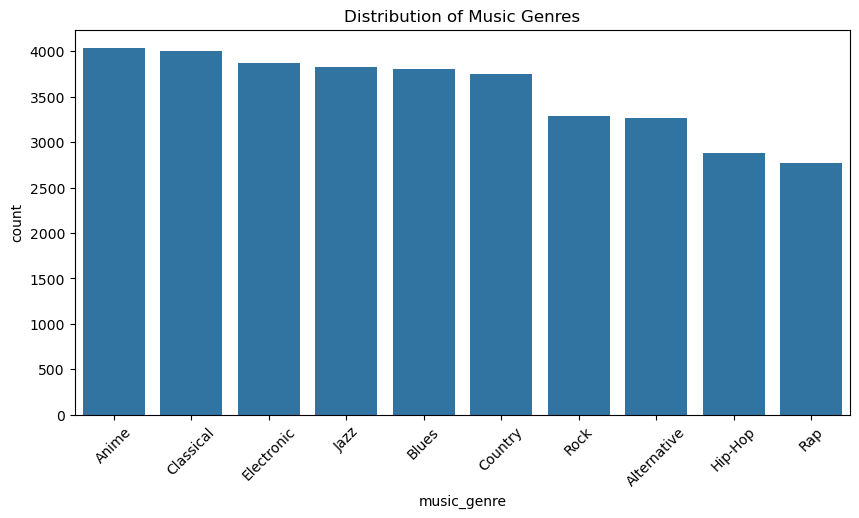

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='music_genre', order=df['music_genre'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Music Genres')
plt.show()

The genre distribution shows moderate class imbalance. Some genres, such as Anime and Classical, contain more examples than others, while Rap and Hip-Hop contain fewer examples. This may bias models toward genres with more training examples and reduce performance on underrepresented classes. To reduce this effect, stratified train-test splitting and Macro F1 were used, since Macro F1 gives equal weight to each genre.


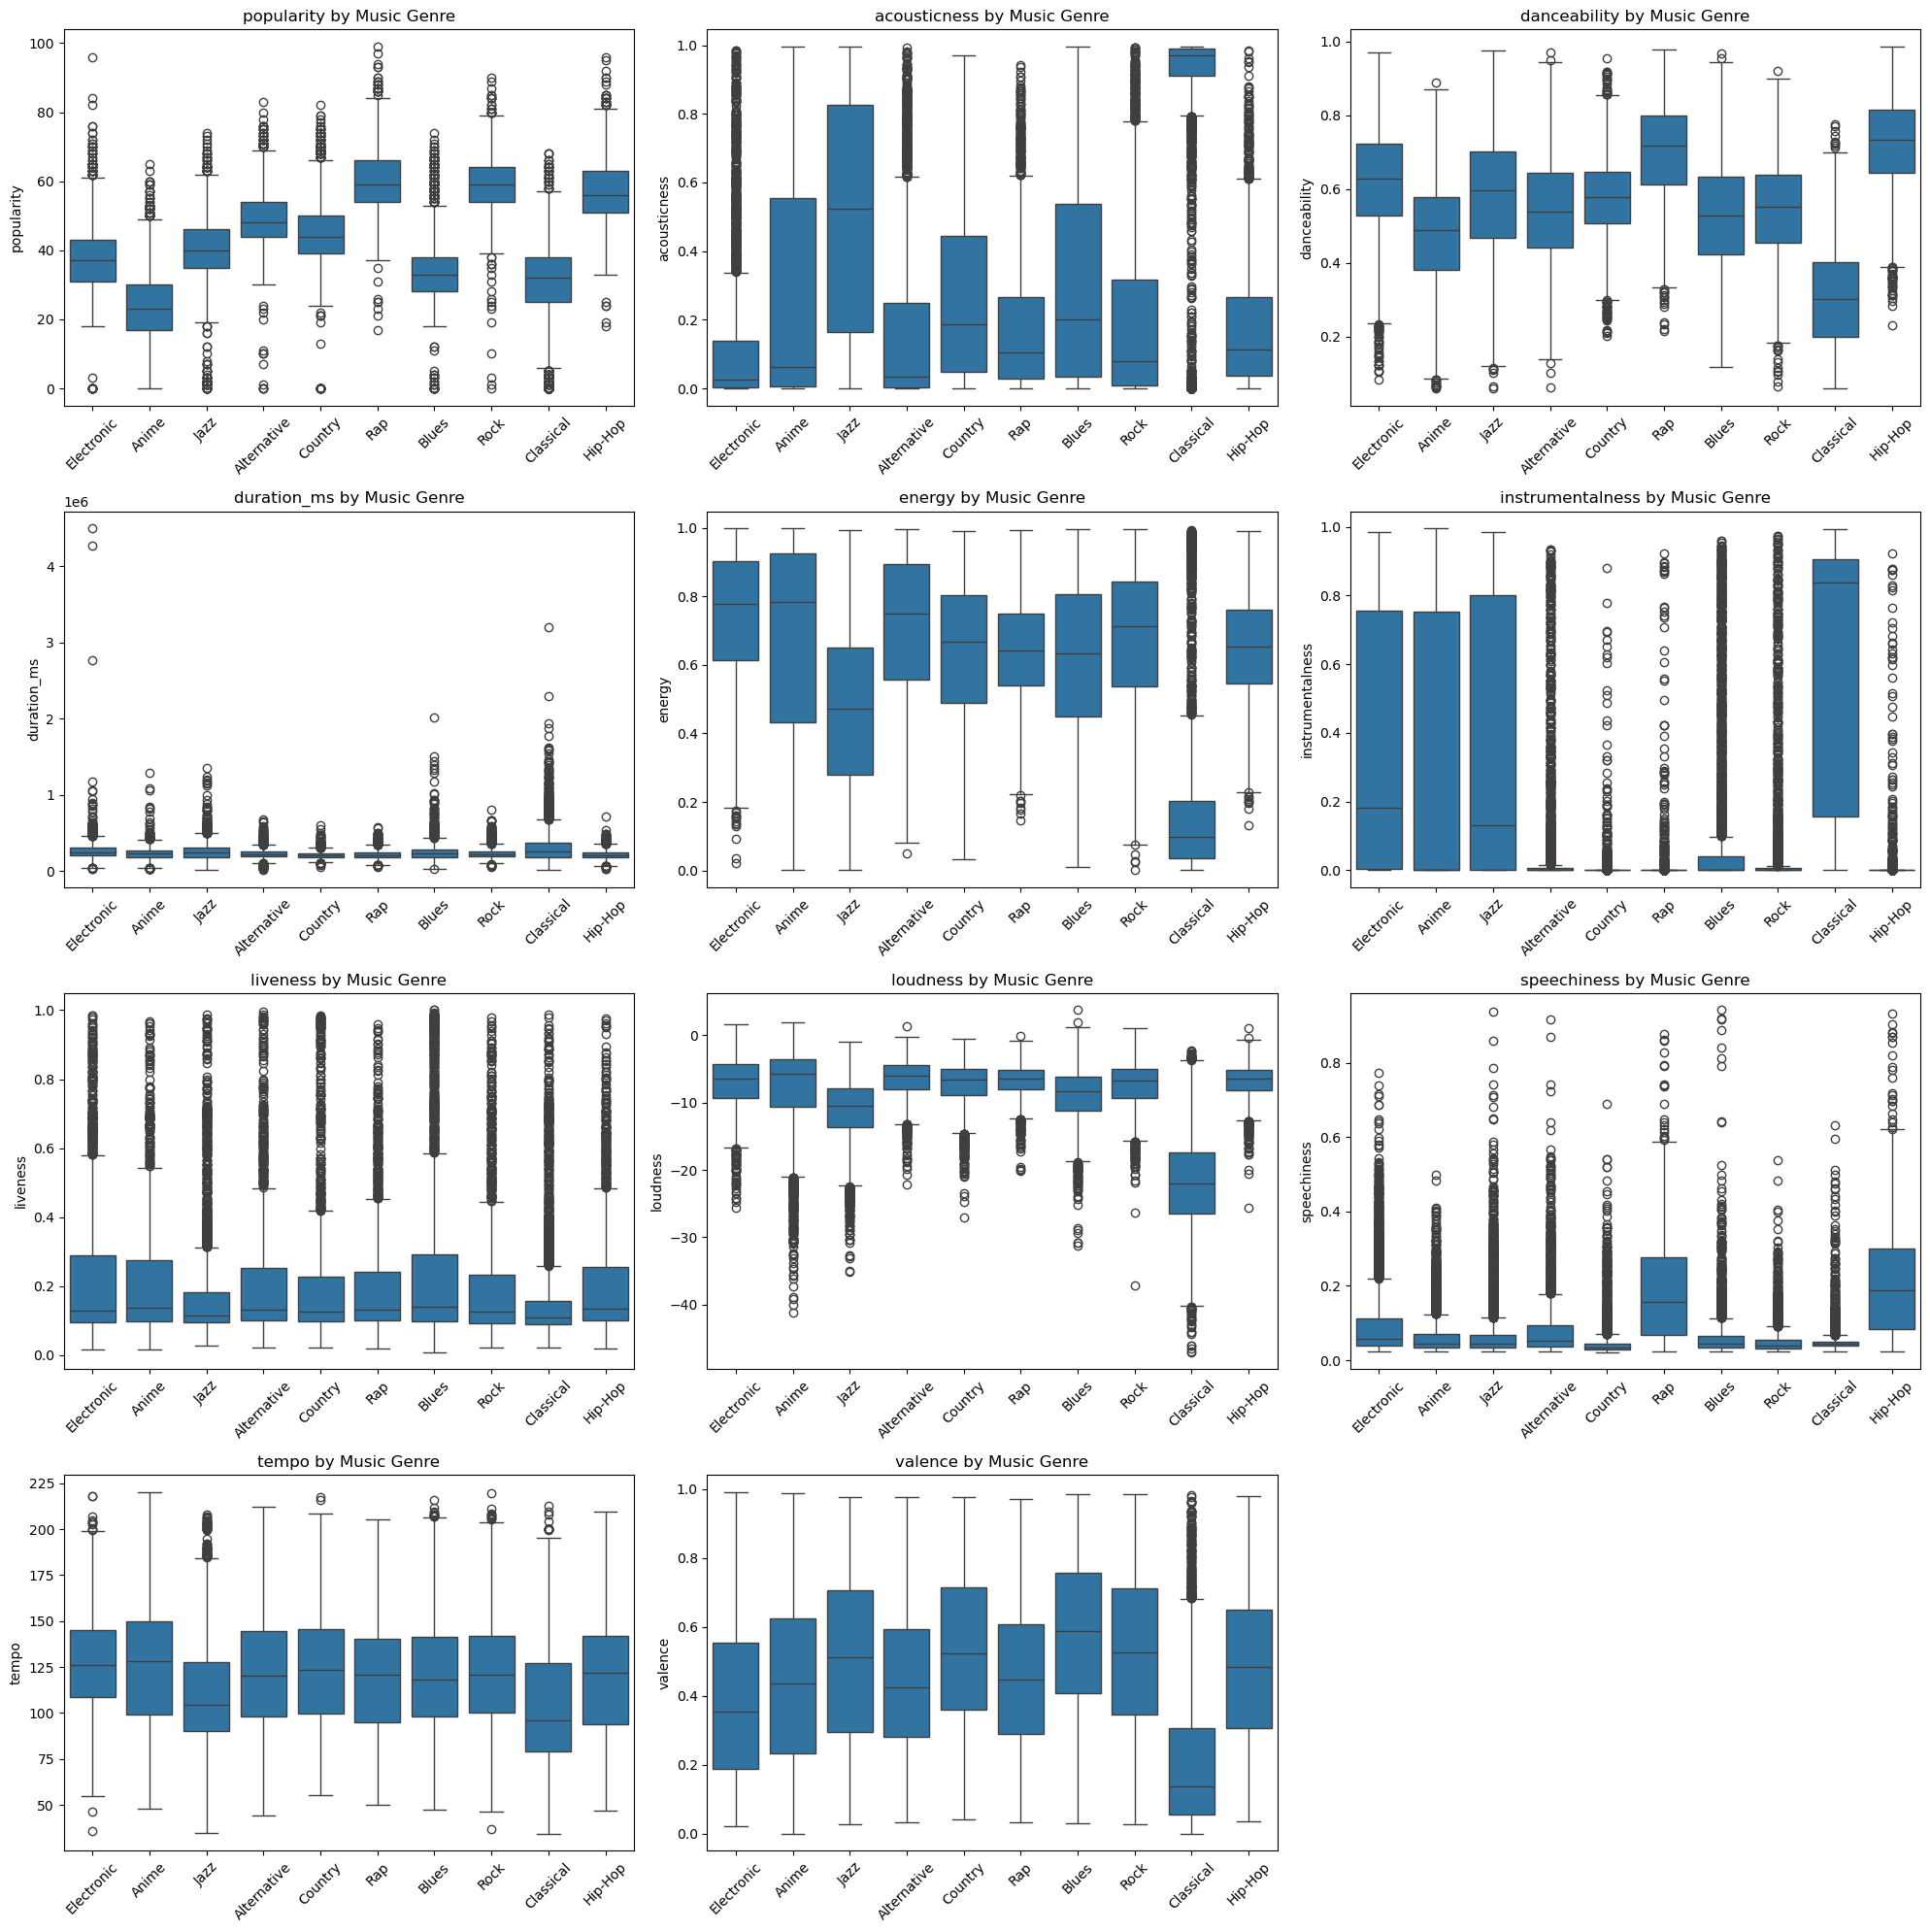

In [6]:
features = ['popularity', 'acousticness', 'danceability', 'duration_ms',
            'energy', 'instrumentalness', 'liveness', 'loudness',
            'speechiness', 'tempo', 'valence']

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='music_genre',
        y=feature,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Music Genre')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

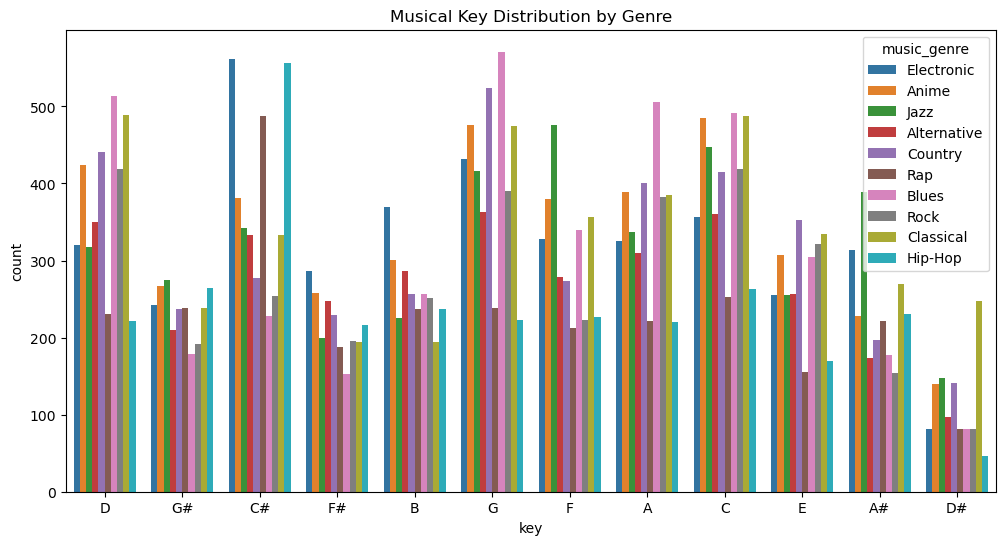

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='key', hue='music_genre')
plt.title('Musical Key Distribution by Genre')
plt.show()

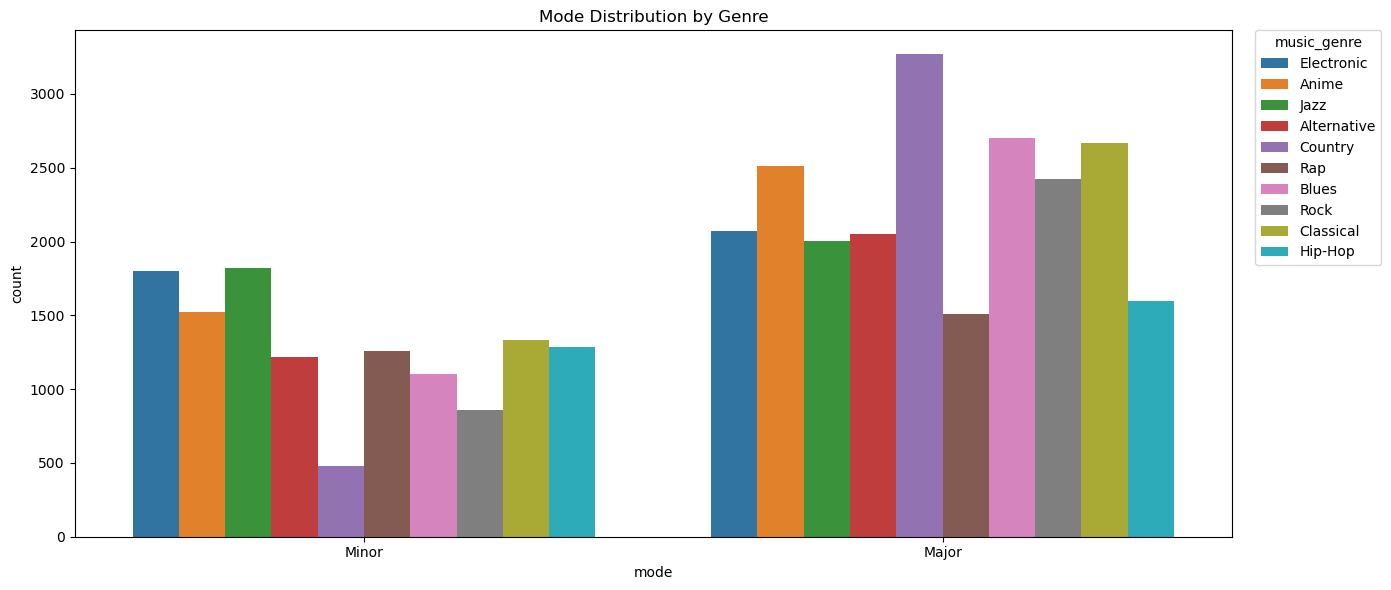

In [8]:
plt.figure(figsize=(14, 6))

ax = sns.countplot(data=df, x='mode', hue='music_genre')

plt.title('Mode Distribution by Genre')
plt.xlabel('mode')
plt.ylabel('count')

plt.legend(
    title='music_genre',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


It is shown that for some genres, such as country and rock, mode can be an indicative feature to the genre classification. Additionally, popularity has a large influence on genre as the violin plot shows distinct popularity values for each genre.

## Feature Engineering

New interaction features were created to capture relationships between audio properties. For example, energy and danceability together may help distinguish high-energy dance genres from genres that are energetic but less dance-oriented. Tempo was grouped into broad BPM categories using musically interpretable thresholds. Songs below 90 BPM were treated as slow, 90-120 BPM as medium, 120-160 BPM as fast, and above 160 BPM as very fast.

In [9]:
df['duration_min'] = df['duration_ms'] / 60000
df = df.drop(columns=['duration_ms'])
df['energy_danceability'] = df['energy'] * df['danceability']
df['energy_valence'] = df['energy'] * df['valence']
df['acoustic_instrumental'] = df['acousticness'] * df['instrumentalness']
df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')
df = df.dropna(subset=['tempo']).reset_index(drop=True)
df['tempo_category'] = pd.cut(
    df['tempo'],
    bins=[0, 90, 120, 160, float('inf')],
    labels=['slow', 'medium', 'fast', 'very_fast']
)

In [10]:
target_col = 'music_genre'

categorical_cols = ['key', 'mode', 'tempo_category']
# mode is binary so drop='first' removes it to one column, meaning 1 for minor and 0 for major
encoder = OneHotEncoder(drop = 'first',sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoded_cols,
    index=df.index
)
df_encoded = pd.concat([df, encoded_df], axis=1)
df_encoded = df_encoded.drop(categorical_cols, axis=1)
X = df_encoded.drop(columns=target_col)
y = df_encoded[target_col]

## Feature selection with KNN

A univariate filter method was used for feature selection. Each feature was ranked independently using mutual information with the target genre. This method was chosen because it is classifier-independent, allowing the same selected feature subset to be used across all models. Mutual information was preferred because it can capture non-linear relationships between individual features and the multiclass target.


Mutual Information Scores for Features:
                     Feature  MI Score
0                 popularity  0.615074
13     acoustic_instrumental  0.324213
1               acousticness  0.299234
6                   loudness  0.297897
11       energy_danceability  0.296441
3                     energy  0.288549
4           instrumentalness  0.280084
2               danceability  0.247710
12            energy_valence  0.205490
7                speechiness  0.203759
8                      tempo  0.152375
10              duration_min  0.117144
9                    valence  0.115889
25                mode_Minor  0.026277
27       tempo_category_slow  0.023990
5                   liveness  0.023242
17                    key_C#  0.008286
28  tempo_category_very_fast  0.005027
26     tempo_category_medium  0.004955
14                    key_A#  0.002441
19                    key_D#  0.002346
18                     key_D  0.002181
23                     key_G  0.001921
15                     k

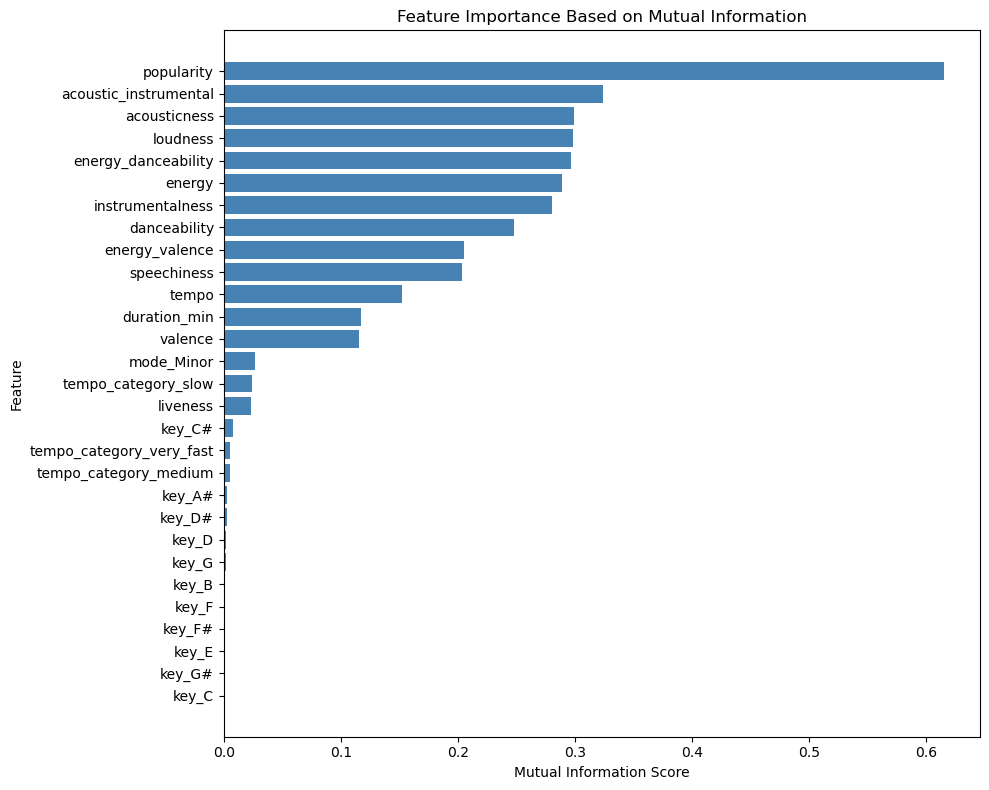

In [11]:
discrete_features = X.columns.str.startswith(('key_', 'mode_','tempo_category'))

mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)

print("Mutual Information Scores for Features:")
print(mi_df)

plt.figure(figsize=(10, 8))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mutual Information")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Although popularity is not a musical feature, it was retained because it may contain useful genre-related information. For example, some genres may have different popularity patterns on streaming platforms, so this feature could help improve classification performance. However, it may reflect listener behavior or platform trends rather than the sound of the track so classification across multiple platforms would be incorrect. Later on, we will model with probability and without, to answer if only audio properties can be used to identify genres.


A correlation heatmap for redundancy checks whether some features are giving almost the same information.



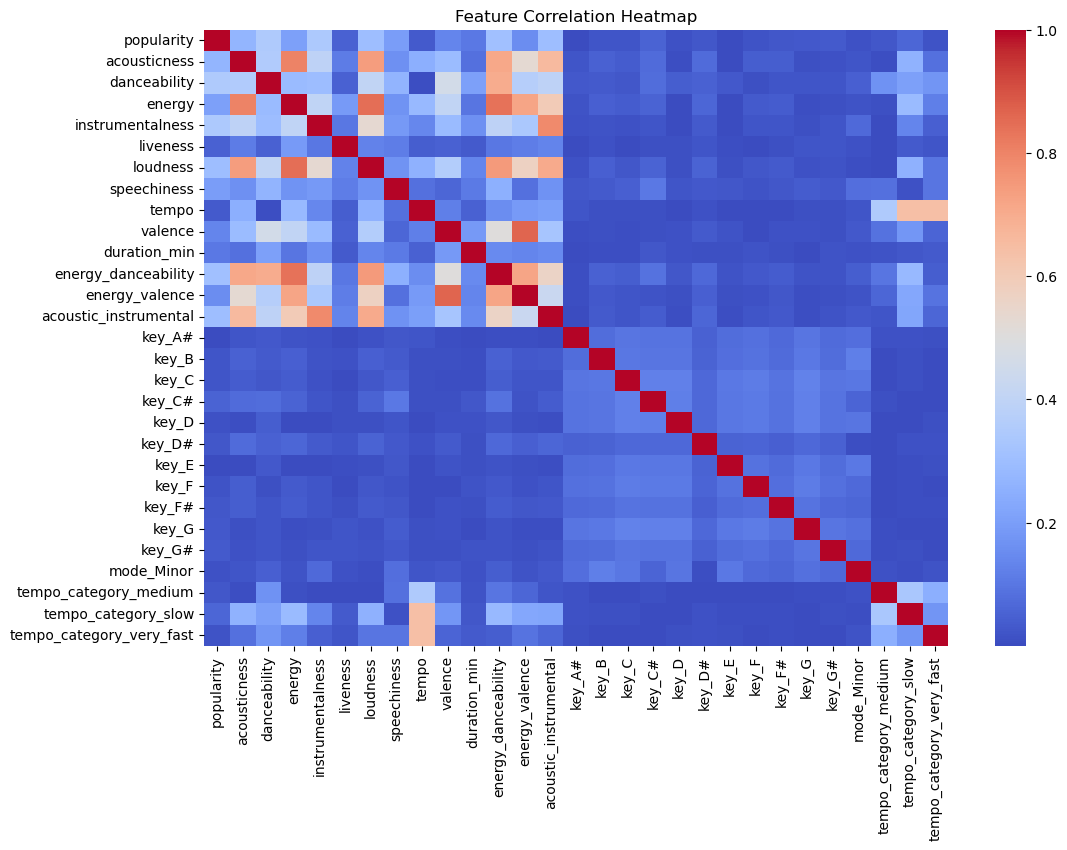

In [12]:
corr_matrix = X.corr().abs()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

KNN was used as a simple validation model to choose the number of selected features. The resulting feature subset was then shared across all models for fair comparison.


The data was split into training and test sets using stratified sampling so that the genre distribution remained similar in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Implementing cross-validation on the training set to select features.

In [14]:
cross_validation = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)
max_features = X_train.shape[1]

k_options = [5, 10, 15, 20, 25, max_features]
k_options = sorted(set(k for k in k_options if k <= max_features))


In [15]:
feature_selection_results = []

discrete_feature_mask = X_train.columns.str.startswith(
    ("key_", "mode_", "tempo_category_")
)
for k in k_options:
    fold_scores = []

    for train_index, validation_index in cross_validation.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        

        selector = SelectKBest(
            score_func=lambda X_data, y_data: mutual_info_classif(
                X_data,
                y_data,
                discrete_features=discrete_feature_mask,
                random_state=42
            ),
            k=k
        )

        X_fold_train_selected = selector.fit_transform(
            X_fold_train,
            y_fold_train
        )

        X_fold_validation_selected = selector.transform(
            X_fold_validation
        )

        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train_selected)
        X_fold_validation_scaled = scaler.transform(X_fold_validation_selected)

        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_fold_train_scaled, y_fold_train)

        y_fold_pred = model.predict(X_fold_validation_scaled)

        fold_score = f1_score(
            y_fold_validation,
            y_fold_pred,
            average="macro",
            zero_division=0
        )

        fold_scores.append(fold_score)

    feature_selection_results.append({
        "k": k,
        "Mean CV Macro F1": np.mean(fold_scores),
        "Std CV Macro F1": np.std(fold_scores)
    })

feature_selection_results_df = pd.DataFrame(feature_selection_results)
feature_selection_results_df


,k,Mean CV Macro F1,Std CV Macro F1
0,5,0.422916,0.002845
1,10,0.503599,0.003682
2,15,0.505415,0.002473
3,20,0.475998,0.004992
4,25,0.443416,0.001465
5,29,0.423376,0.002757


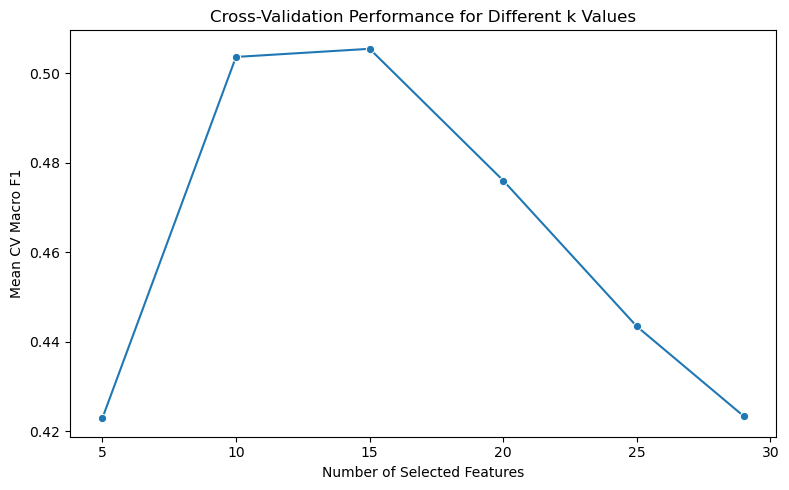

Best k: 15


In [16]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=feature_selection_results_df,
    x="k",
    y="Mean CV Macro F1",
    marker="o"
)
plt.title("Cross-Validation Performance for Different k Values")
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV Macro F1")
plt.tight_layout()
plt.show()

best_k = int(
    feature_selection_results_df.sort_values(
        by="Mean CV Macro F1",
        ascending=False
    ).iloc[0]["k"]
)

print("Best k:", best_k)


In [17]:
final_selector = SelectKBest(
    score_func=lambda X_data, y_data: mutual_info_classif(
        X_data,
        y_data,
        discrete_features=discrete_feature_mask,
        random_state=42
    ),
    k=best_k
)

X_train_selected = final_selector.fit_transform(X_train, y_train)
X_test_selected = final_selector.transform(X_test)

selected_features = X_train.columns[final_selector.get_support()].tolist()

print("Selected features:")
for feature in selected_features:
    print("-", feature)


Selected features:
- popularity
- acousticness
- danceability
- energy
- instrumentalness
- liveness
- loudness
- speechiness
- tempo
- valence
- duration_min
- energy_danceability
- energy_valence
- acoustic_instrumental
- mode_Minor


## Data Modelling

Genre is a categorical target, so this section compares classification models. The models include KNN, Decision Tree, Random Forest, a neural network using MLP, and a stacking ensemble.
KNN is instance-based and sensitive to local feature similarity. Decision Trees can learn non-linear decision rules, while Random Forest extends this idea by combining many trees to reduce overfitting and improve stability. The MLP neural network can learn non-linear feature interactions, while stacking combines predictions from several base classifiers through a meta-classifier.
All models use the same train/test split, the same selected feature set, and stratified cross-validation for hyperparameter tuning.


In [18]:
models = {
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "model__n_neighbors": [5, 11, 15, 21, 25, 31],
            "model__weights": ["uniform", "distance"]
        }
    },

    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        "params": {
            "model__max_depth": [5, 10, 15, None],
            "model__min_samples_leaf": [1, 5, 10]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [10, 20, None]
        }
    }
}

In [19]:
test_results = []
hyperparameter_results = []
conf_matrices = {}
best_models = {}
class_names = sorted(y_test.unique())

for name, config in models.items():
    print()
    print("Tuning", name)

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring="f1_macro",
        cv=cross_validation,
        n_jobs=1
    )
    grid.fit(X_train_selected, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_selected)

    best_models[name] = best_model
    conf_matrices[name] = confusion_matrix(
        y_test,
        y_pred,
        labels=class_names
    )

    test_results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Test Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0)
    })

    cv_results = pd.DataFrame(grid.cv_results_)
    param_columns = [
        col for col in cv_results.columns
        if col.startswith("param_")
    ]

    main_param = param_columns[0]
    second_param = param_columns[1] if len(param_columns) > 1 else None

    for _, row in cv_results.iterrows():
        hyperparameter_results.append({
            "Model": name,
            "Main Hyperparameter": main_param.replace("param_model__", ""),
            "Main Value": str(row[main_param]),
            "Second Hyperparameter": (
                second_param.replace("param_model__", "")
                if second_param is not None else None
            ),
            "Second Value": (
                str(row[second_param])
                if second_param is not None else None
            ),
            "Mean CV Macro F1": row["mean_test_score"]
        })

    print("Best parameters:", grid.best_params_)
    print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Test Macro F1:", round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4))


Tuning KNN
Best parameters: {'model__n_neighbors': 25, 'model__weights': 'distance'}
Test Accuracy: 0.5472
Test Macro F1: 0.5347

Tuning Decision Tree
Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1}
Test Accuracy: 0.5364
Test Macro F1: 0.526

Tuning Random Forest
Best parameters: {'model__max_depth': None, 'model__n_estimators': 200}
Test Accuracy: 0.615
Test Macro F1: 0.6007


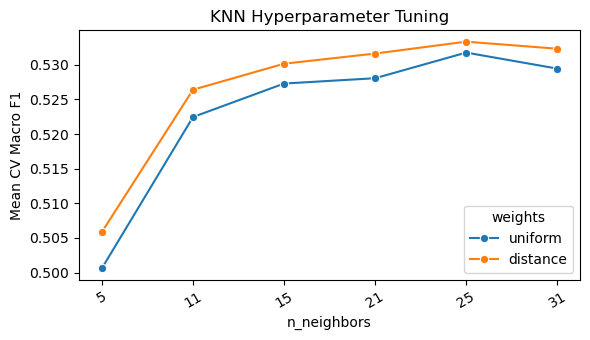

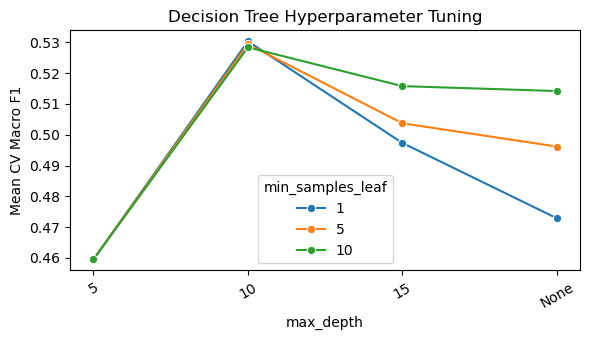

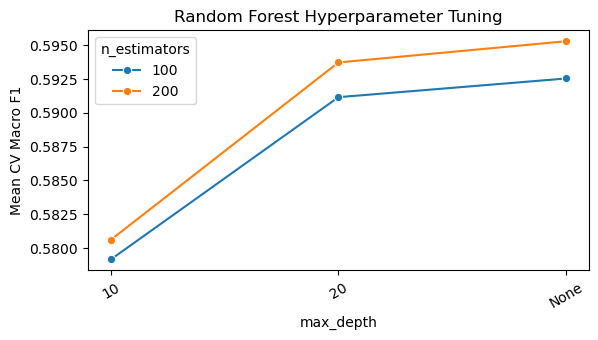

In [20]:
hyperparameter_results_df = pd.DataFrame(hyperparameter_results)

for model_name in hyperparameter_results_df["Model"].unique():
    model_data = hyperparameter_results_df[
        hyperparameter_results_df["Model"] == model_name
    ].copy()

    main_param = model_data["Main Hyperparameter"].iloc[0]
    second_param = model_data["Second Hyperparameter"].iloc[0]

    main_value_order = model_data["Main Value"].drop_duplicates().tolist()
    model_data["Main Value"] = pd.Categorical(
        model_data["Main Value"],
        categories=main_value_order,
        ordered=True
    )

    plt.figure(figsize=(6, 3.5))

    if pd.isna(second_param):
        sns.lineplot(
            data=model_data,
            x="Main Value",
            y="Mean CV Macro F1",
            marker="o"
        )
    else:
        sns.lineplot(
            data=model_data,
            x="Main Value",
            y="Mean CV Macro F1",
            hue="Second Value",
            marker="o"
        )
        plt.legend(title=second_param)

    plt.title(f"{model_name} Hyperparameter Tuning")
    plt.xlabel(main_param)
    plt.ylabel("Mean CV Macro F1")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

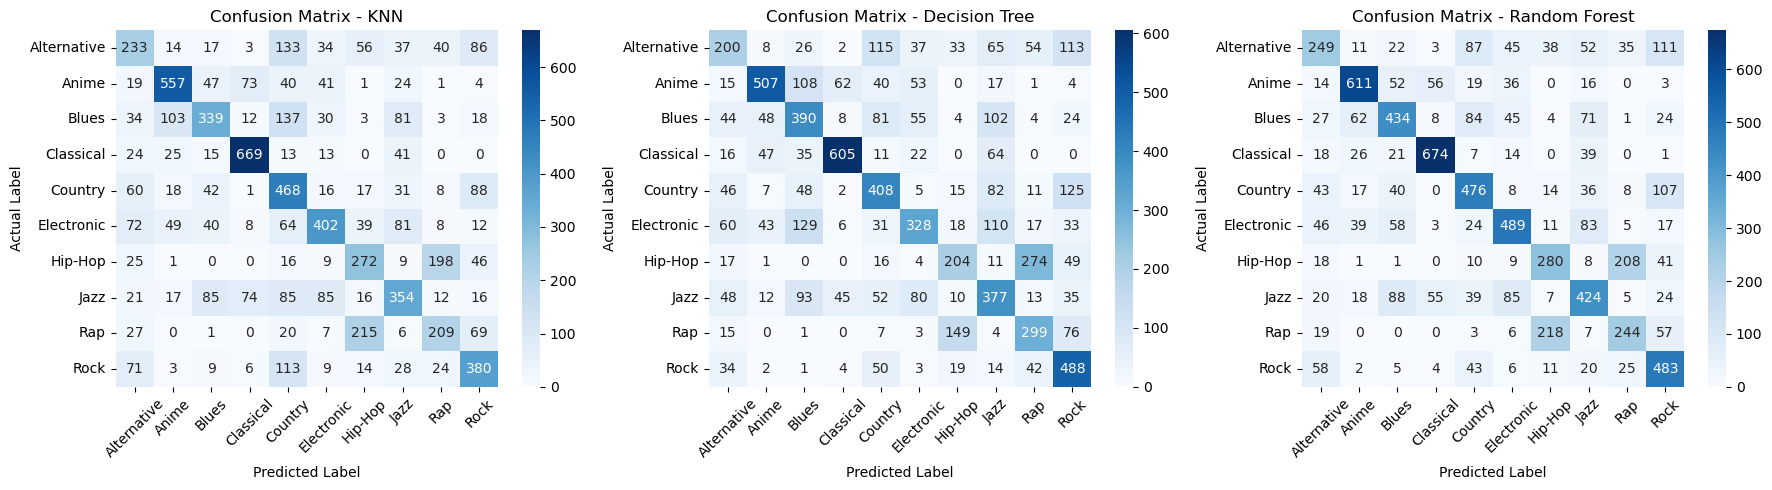

In [21]:
fig, axes = plt.subplots(1, len(conf_matrices), figsize=(18, 5))

for ax, (name, matrix) in zip(axes, conf_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=class_names,
        yticklabels=class_names
    )
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

#### Neural Network

A Multi-Layer Perceptron (MLP) was used as the neural network model. MLP is suitable for this multiclass classification task because it can learn non-linear relationships between the selected audio features and music genre labels. The selected features were standardised before training because neural networks are sensitive to feature scale. The hidden layer size was tuned using cross-validation on the training data.


For the MLP model, alpha controls the strength of L2 regularisation. A larger alpha penalises large network weights more strongly, which can reduce overfitting but may also make the model underfit if the penalty is too strong. Therefore, alpha was tuned together with hidden layer size to balance model complexity and generalisation.


In [22]:
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(max_iter=1000, random_state=42))
])

mlp_params = {
    "model__hidden_layer_sizes": [
        (50,),
        (75,),
        (100,)
    ],
    "model__alpha": [0.0001, 0.001, 0.01]
}

mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_params,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=1
)

mlp_grid.fit(X_train_selected, y_train)

best_mlp = mlp_grid.best_estimator_
best_hidden_layers = mlp_grid.best_params_["model__hidden_layer_sizes"]
best_mlp_alpha = mlp_grid.best_params_["model__alpha"]
y_pred_mlp = best_mlp.predict(X_test_selected)

test_results.append({
    "Model": "MLP Neural Network",
    "Best Parameters": mlp_grid.best_params_,
    "Test Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Test Precision": precision_score(y_test, y_pred_mlp, average="macro", zero_division=0),
    "Test Recall": recall_score(y_test, y_pred_mlp, average="macro", zero_division=0),
    "Test Macro F1": f1_score(y_test, y_pred_mlp, average="macro", zero_division=0)
})

print("Best MLP parameters:", mlp_grid.best_params_)
print("CV Macro F1:", round(mlp_grid.best_score_, 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Test Macro F1:", round(f1_score(y_test, y_pred_mlp, average="macro", zero_division=0), 4))

Best MLP parameters: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (50,)}
CV Macro F1: 0.5963
Test Accuracy: 0.6082
Test Macro F1: 0.5954


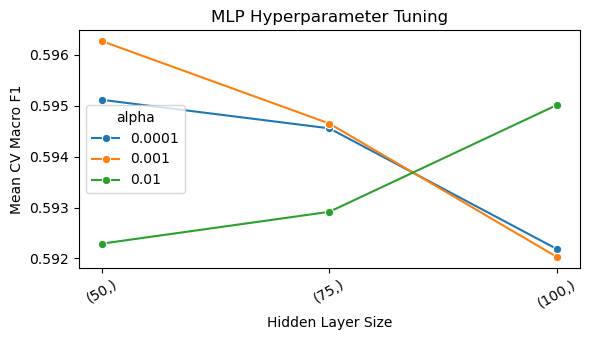

Best hidden layer size: (50,)
Best alpha: 0.001
              precision    recall  f1-score   support

 Alternative       0.45      0.37      0.41       653
       Anime       0.76      0.77      0.76       807
       Blues       0.61      0.55      0.58       760
   Classical       0.86      0.81      0.84       800
     Country       0.57      0.59      0.58       749
  Electronic       0.66      0.62      0.64       775
     Hip-Hop       0.47      0.55      0.51       576
        Jazz       0.55      0.57      0.56       765
         Rap       0.48      0.42      0.45       554
        Rock       0.56      0.73      0.63       657

    accuracy                           0.61      7096
   macro avg       0.60      0.60      0.60      7096
weighted avg       0.61      0.61      0.61      7096



In [23]:
mlp_results_df = pd.DataFrame({
    "hidden_layer_sizes": [
        str(value) for value in mlp_grid.cv_results_["param_model__hidden_layer_sizes"]
    ],
    "alpha": [
        str(value) for value in mlp_grid.cv_results_["param_model__alpha"]
    ],
    "Mean CV Macro F1": mlp_grid.cv_results_["mean_test_score"],
    "Std CV Macro F1": mlp_grid.cv_results_["std_test_score"]
})

hidden_layer_order = mlp_results_df["hidden_layer_sizes"].drop_duplicates().tolist()
mlp_results_df["hidden_layer_sizes"] = pd.Categorical(
    mlp_results_df["hidden_layer_sizes"],
    categories=hidden_layer_order,
    ordered=True
)

plt.figure(figsize=(6, 3.5))
sns.lineplot(
    data=mlp_results_df,
    x="hidden_layer_sizes",
    y="Mean CV Macro F1",
    hue="alpha",
    marker="o"
)
plt.title("MLP Hyperparameter Tuning")
plt.xlabel("Hidden Layer Size")
plt.ylabel("Mean CV Macro F1")
plt.xticks(rotation=30)
plt.legend(title="alpha")
plt.tight_layout()
plt.show()

mlp_results_df
print("Best hidden layer size:", best_hidden_layers)
print("Best alpha:", best_mlp_alpha)
print(classification_report(y_test, y_pred_mlp, zero_division=0))

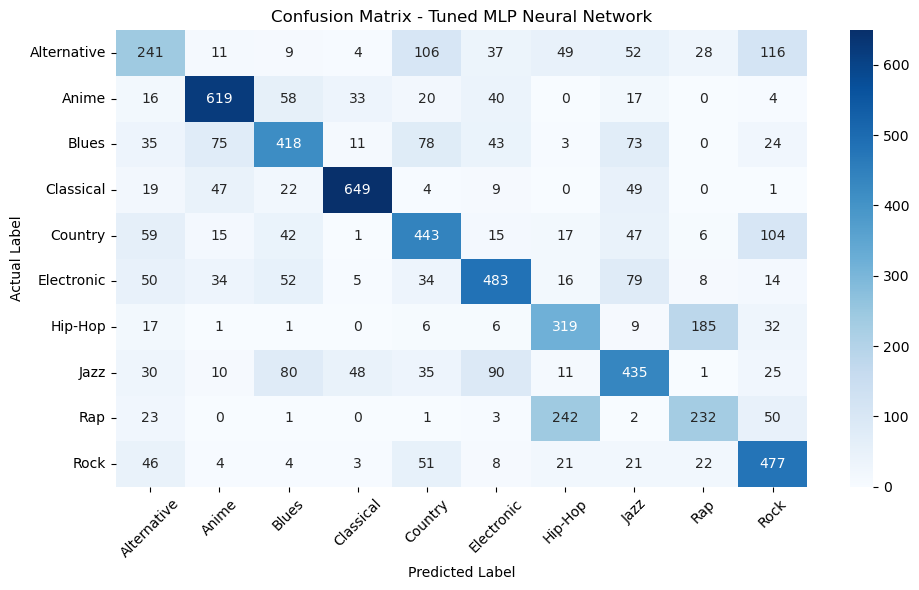

In [24]:
class_names = sorted(y_test.unique())

mlp_conf_matrix = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=class_names
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    mlp_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Tuned MLP Neural Network")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Ensemble Methods

A stacking ensemble was used to test whether combining several classifiers could improve performance. The base models were KNN, Decision Tree, and Random Forest, which make different assumptions about the feature space. Logistic Regression was used as the meta-classifier because it provides a simple and interpretable way to combine the probability outputs from the base models.

The stacking classifier uses cross-validation to generate out-of-fold predictions for the meta-classifier. This is important because the meta-classifier should learn from predictions made on data that the base models did not directly train on, reducing the risk of overfitting.

In [25]:
stacking_base_models = [
    ("KNN", best_models["KNN"]),
    ("Decision Tree", best_models["Decision Tree"]),
    ("Random Forest", best_models["Random Forest"])
]

stacking_model = StackingClassifier(
    estimators=stacking_base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    stack_method="predict_proba",
    cv=cross_validation,
    n_jobs=1
)

stacking_params = {
    "final_estimator__C": [0.1, 1, 10],
    "final_estimator__class_weight": [None, "balanced"]
}

stacking_grid = GridSearchCV(
    estimator=stacking_model,
    param_grid=stacking_params,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=1
)
stacking_grid.fit(X_train_selected, y_train)

best_stacking_model = stacking_grid.best_estimator_
y_pred_stack = best_stacking_model.predict(X_test_selected)

test_results.append({
    "Model": "Stacking Ensemble",
    "Best Parameters": stacking_grid.best_params_,
    "Test Accuracy": accuracy_score(y_test, y_pred_stack),
    "Test Precision": precision_score(y_test, y_pred_stack, average="macro", zero_division=0),
    "Test Recall": recall_score(y_test, y_pred_stack, average="macro", zero_division=0),
    "Test Macro F1": f1_score(y_test, y_pred_stack, average="macro", zero_division=0)
})

print("Best Stacking Parameters:", stacking_grid.best_params_)
print("CV Macro F1:", round(stacking_grid.best_score_, 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_stack), 4))
print("Test Macro F1:", round(f1_score(y_test, y_pred_stack, average="macro", zero_division=0), 4))
print(classification_report(y_test, y_pred_stack, zero_division=0))

Best Stacking Parameters: {'final_estimator__C': 1, 'final_estimator__class_weight': 'balanced'}
CV Macro F1: 0.6006
Test Accuracy: 0.6178
Test Macro F1: 0.6082
              precision    recall  f1-score   support

 Alternative       0.43      0.44      0.44       653
       Anime       0.79      0.75      0.77       807
       Blues       0.60      0.59      0.59       760
   Classical       0.87      0.81      0.84       800
     Country       0.63      0.59      0.61       749
  Electronic       0.68      0.62      0.64       775
     Hip-Hop       0.53      0.46      0.49       576
        Jazz       0.55      0.57      0.56       765
         Rap       0.47      0.54      0.50       554
        Rock       0.57      0.72      0.64       657

    accuracy                           0.62      7096
   macro avg       0.61      0.61      0.61      7096
weighted avg       0.62      0.62      0.62      7096



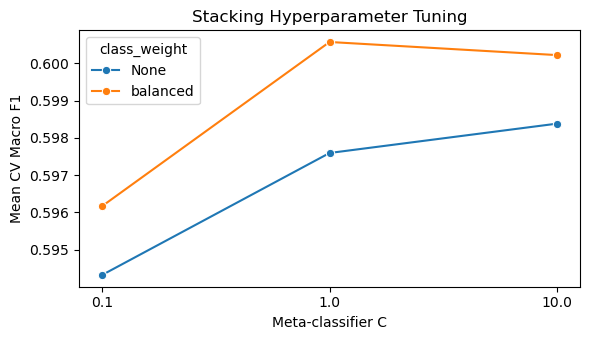

,C,class_weight,Mean CV Macro F1
0,0.1,None,0.594321
1,0.1,balanced,0.596165
2,1.0,None,0.597594
3,1.0,balanced,0.600570
4,10.0,None,0.598381
5,10.0,balanced,0.600218


In [26]:
stacking_results_df = pd.DataFrame({
    "C": [
        str(value) for value in stacking_grid.cv_results_["param_final_estimator__C"]
    ],
    "class_weight": [
        str(value) for value in stacking_grid.cv_results_["param_final_estimator__class_weight"]
    ],
    "Mean CV Macro F1": stacking_grid.cv_results_["mean_test_score"]
})

c_order = stacking_results_df["C"].drop_duplicates().tolist()
stacking_results_df["C"] = pd.Categorical(
    stacking_results_df["C"],
    categories=c_order,
    ordered=True
)

plt.figure(figsize=(6, 3.5))
sns.lineplot(
    data=stacking_results_df,
    x="C",
    y="Mean CV Macro F1",
    hue="class_weight",
    marker="o"
)
plt.title("Stacking Hyperparameter Tuning")
plt.xlabel("Meta-classifier C")
plt.ylabel("Mean CV Macro F1")
plt.legend(title="class_weight")
plt.tight_layout()
plt.show()

stacking_results_df

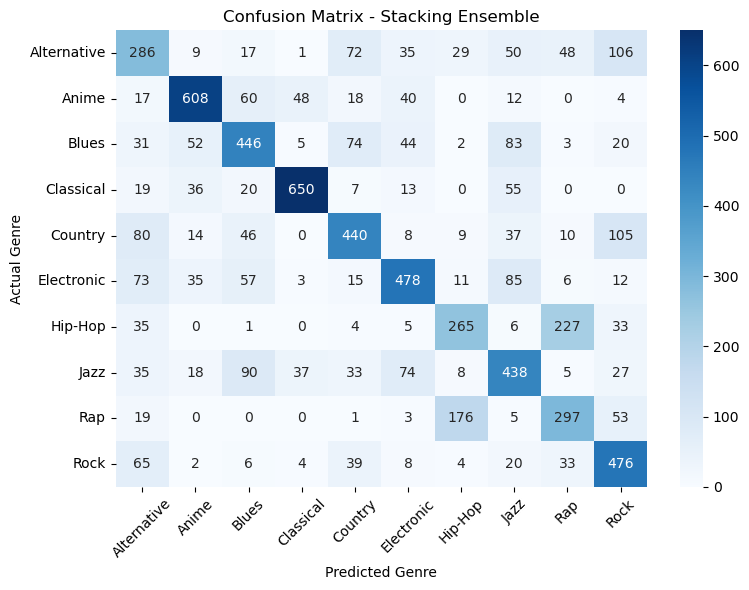

In [27]:
stacking_conf_matrix = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(8, 6))
sns.heatmap(
    stacking_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title("Confusion Matrix - Stacking Ensemble")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
results_df = pd.DataFrame(test_results)

score_columns = [
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test Macro F1"
]

results_df[score_columns] = results_df[score_columns].round(4)
results_df

,Model,Best Parameters,Test Accuracy,Test Precision,Test Recall,Test Macro F1
0,KNN,"{'model__n_neighbors': 25, 'model__weights': '...",0.5472,0.5403,0.5363,0.5347
1,Decision Tree,"{'model__max_depth': 10, 'model__min_samples_l...",0.5364,0.5338,0.5301,0.5260
2,Random Forest,"{'model__max_depth': None, 'model__n_estimator...",0.6150,0.6020,0.6034,0.6007
3,MLP Neural Network,"{'model__alpha': 0.001, 'model__hidden_layer_s...",0.6082,0.5975,0.5979,0.5954
4,Stacking Ensemble,"{'final_estimator__C': 1, 'final_estimator__cl...",0.6178,0.6110,0.6088,0.6082


## Additional Analysis: Merging Rap and Hip-Hop

The confusion matrices showed that Rap and Hip-Hop were frequently misclassified as each other. This is understandable because the two labels are musically and culturally related, and the boundary between them may be ambiguous in the dataset.

An additional experiment was conducted by merging Rap and Hip-Hop into one class, Rap/Hip-Hop. This allows us to test whether overlapping labels were limiting model performance.

This was tested using the tuned model with the highest Macro F1 as macro results take into account imbalance of classes.

In [29]:
best_model_name = results_df.sort_values(
    by="Test Macro F1",
    ascending=False
).iloc[0]["Model"]

print("Best model from main experiment:", best_model_name)

Best model from main experiment: Stacking Ensemble


In [30]:
y_merged = y.replace({
    "Rap": "Rap/Hip-Hop",
    "Hip-Hop": "Rap/Hip-Hop"
})


In [31]:
# Use the same train/test validation approach
X_train_merged, X_test_merged, y_train_merged, y_test_merged = train_test_split(
    X,
    y_merged,
    test_size=0.2,
    random_state=42,
    stratify=y_merged
)

# Refit feature selection using only the merged training data
discrete_feature_mask_merged = X_train_merged.columns.str.startswith(
    ("key_", "mode_", "tempo_category_")
)

merged_selector = SelectKBest(
    score_func=lambda X_data, y_data: mutual_info_classif(
        X_data,
        y_data,
        discrete_features=discrete_feature_mask_merged,
        random_state=42
    ),
    k=int(best_k)
)

X_train_merged_selected = merged_selector.fit_transform(
    X_train_merged,
    y_train_merged
)

X_test_merged_selected = merged_selector.transform(X_test_merged)

merged_selected_features = X_train_merged.columns[
    merged_selector.get_support()
].tolist()

print("Selected features for merged-label experiment:")
for feature in merged_selected_features:
    print("-", feature)


Selected features for merged-label experiment:
- popularity
- acousticness
- danceability
- energy
- instrumentalness
- loudness
- speechiness
- tempo
- valence
- duration_min
- energy_danceability
- energy_valence
- acoustic_instrumental
- mode_Minor
- tempo_category_slow


In [32]:
stacking_merged = StackingClassifier(
    estimators=stacking_base_models,
    final_estimator=LogisticRegression(
        C=stacking_grid.best_params_["final_estimator__C"],
        class_weight=stacking_grid.best_params_["final_estimator__class_weight"],
        max_iter=1000,
        random_state=42
    ),
    stack_method="predict_proba",
    cv=cross_validation,
    n_jobs=1
)

stacking_merged.fit(X_train_merged_selected, y_train_merged)
y_pred_stack_merged = stacking_merged.predict(X_test_merged_selected)

merged_accuracy = accuracy_score(y_test_merged, y_pred_stack_merged)
merged_macro_f1 = f1_score(
    y_test_merged,
    y_pred_stack_merged,
    average="macro",
    zero_division=0
)

print("Stacking Ensemble with Rap/Hip-Hop merged")
print("Accuracy:", round(merged_accuracy, 4))
print("Macro F1:", round(merged_macro_f1, 4))
print(classification_report(y_test_merged, y_pred_stack_merged, zero_division=0))

Stacking Ensemble with Rap/Hip-Hop merged
Accuracy: 0.6702
Macro F1: 0.6567
              precision    recall  f1-score   support

 Alternative       0.42      0.43      0.43       653
       Anime       0.80      0.76      0.78       807
       Blues       0.60      0.58      0.59       760
   Classical       0.86      0.82      0.84       800
     Country       0.61      0.61      0.61       749
  Electronic       0.67      0.61      0.64       775
        Jazz       0.57      0.57      0.57       766
 Rap/Hip-Hop       0.85      0.83      0.84      1129
        Rock       0.55      0.71      0.62       657

    accuracy                           0.67      7096
   macro avg       0.66      0.66      0.66      7096
weighted avg       0.68      0.67      0.67      7096



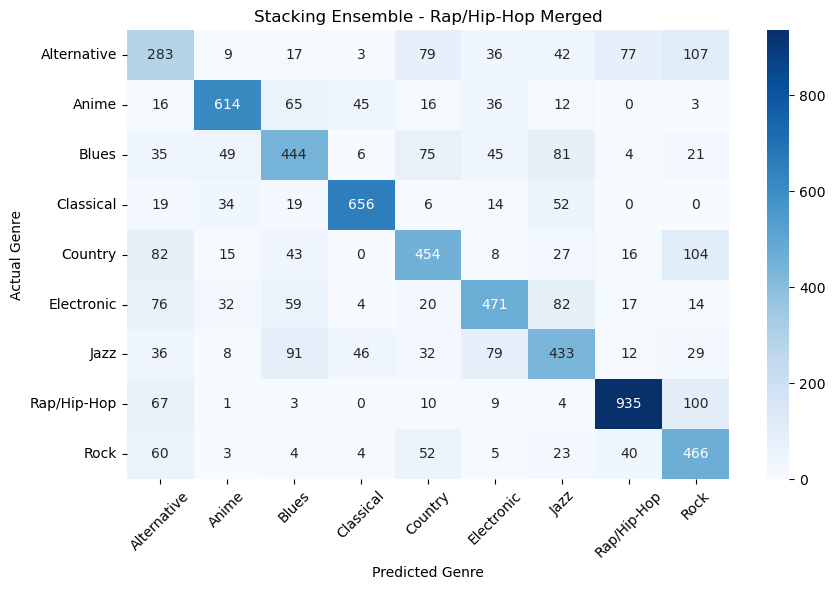

In [33]:
class_names_merged = sorted(y_test_merged.unique())

matrix = confusion_matrix(
    y_test_merged,
    y_pred_stack_merged,
    labels=class_names_merged
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_merged,
    yticklabels=class_names_merged
)

plt.title("Stacking Ensemble - Rap/Hip-Hop Merged")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Additional Analysis: Removing popularity

Popularity was a strong feature during classification, however as stated above, it is not a music feature. This section looks into how well classification with only musical features will be.

This tests whether genre classification performance depends strongly on popularity, or whether the model can still classify genres using audio-based features only.

In [34]:
X_no_popularity = X.drop(columns=["popularity"])

In [35]:
# Use the same train/test validation approach
X_train_no_pop, X_test_no_pop, y_train_no_pop, y_test_no_pop = train_test_split(
    X_no_popularity,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Refit feature selection using only the no-popularity training data
discrete_feature_mask_no_pop = X_train_no_pop.columns.str.startswith(
    ("key_", "mode_", "tempo_category_")
)

selector_no_pop = SelectKBest(
    score_func=lambda X_data, y_data: mutual_info_classif(
        X_data,
        y_data,
        discrete_features=discrete_feature_mask_no_pop,
        random_state=42
    ),
    k=int(best_k)
)

X_train_no_pop_selected = selector_no_pop.fit_transform(
    X_train_no_pop,
    y_train_no_pop
)

X_test_no_pop_selected = selector_no_pop.transform(X_test_no_pop)

selected_features_no_pop = X_train_no_pop.columns[
    selector_no_pop.get_support()
].tolist()

print("Selected features without popularity:")
for feature in selected_features_no_pop:
    print("-", feature)

Selected features without popularity:
- acousticness
- danceability
- energy
- instrumentalness
- liveness
- loudness
- speechiness
- tempo
- valence
- duration_min
- energy_danceability
- energy_valence
- acoustic_instrumental
- mode_Minor
- tempo_category_slow


In [36]:
stacking_no_popularity = StackingClassifier(
    estimators=stacking_base_models,
    final_estimator=LogisticRegression(
        C=stacking_grid.best_params_["final_estimator__C"],
        class_weight=stacking_grid.best_params_["final_estimator__class_weight"],
        max_iter=1000,
        random_state=42
    ),
    stack_method="predict_proba",
    cv=cross_validation,
    n_jobs=1
)

stacking_no_popularity.fit(X_train_no_pop_selected, y_train_no_pop)
y_pred_no_pop = stacking_no_popularity.predict(X_test_no_pop_selected)

no_pop_accuracy = accuracy_score(y_test_no_pop, y_pred_no_pop)
no_pop_macro_f1 = f1_score(
    y_test_no_pop,
    y_pred_no_pop,
    average="macro",
    zero_division=0
)

print("Stacking Ensemble without popularity")
print("Accuracy:", round(no_pop_accuracy, 4))
print("Macro F1:", round(no_pop_macro_f1, 4))
print(classification_report(y_test_no_pop, y_pred_no_pop, zero_division=0))

Stacking Ensemble without popularity
Accuracy: 0.4815
Macro F1: 0.4639
              precision    recall  f1-score   support

 Alternative       0.27      0.30      0.29       653
       Anime       0.57      0.54      0.56       807
       Blues       0.38      0.42      0.40       760
   Classical       0.83      0.81      0.82       800
     Country       0.49      0.57      0.52       749
  Electronic       0.58      0.58      0.58       775
     Hip-Hop       0.43      0.56      0.49       576
        Jazz       0.49      0.48      0.48       765
         Rap       0.38      0.30      0.33       554
        Rock       0.21      0.14      0.17       657

    accuracy                           0.48      7096
   macro avg       0.46      0.47      0.46      7096
weighted avg       0.48      0.48      0.48      7096



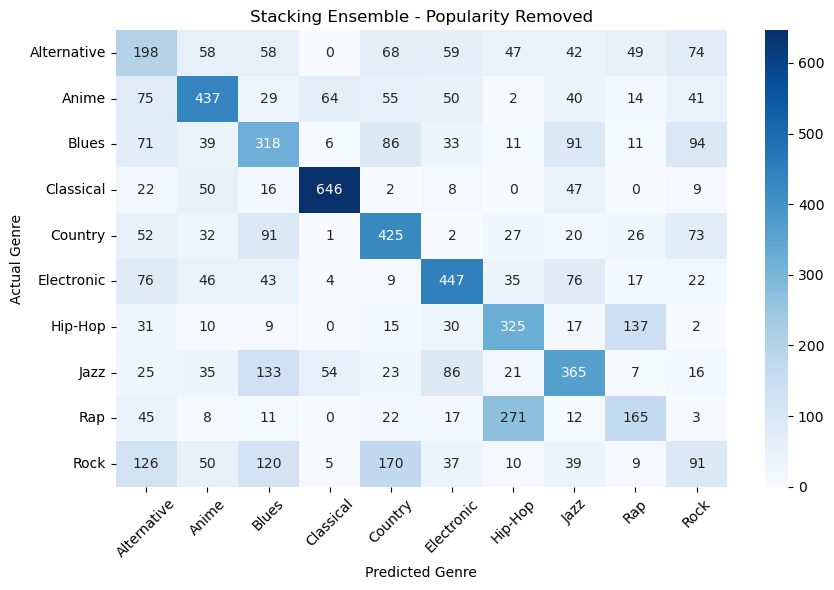

In [37]:
class_names_no_pop = sorted(y_test_no_pop.unique())

matrix = confusion_matrix(
    y_test_no_pop,
    y_pred_no_pop,
    labels=class_names_no_pop
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_no_pop,
    yticklabels=class_names_no_pop
)

plt.title("Stacking Ensemble - Popularity Removed")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Alternative was one of the most ambiguous classes because it may describe a style across several genres rather than a clearly separable genre. This likely contributed to misclassification with Rock, Country, and other related classes.
